In [ ]:
# Only run if needed
!pip install skyfield numpy pandas matplotlib cartopy spacetrack obspy

Drive + path layout

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

ROOT = Path("/content/drive/MyDrive/Johns_Hopkins_University/Seismic_Research")
ORBITS = ROOT / "orbits"
TLE_CACHE = ROOT / "tle_cache"

RAW = ROOT / "raw"
run_id = "shenzhou15_20240402T084000Z_to_20240402T090000Z"
RUN = RAW / run_id

# For the tiling pipeline, everything goes under RUN/boxes/box_xxx/...
BOXES = RUN / "boxes"

# Keep these if you also want a "whole-run" (non-boxed) download option
WAVE = RUN / "boxes"  # Changed from waveforms
META = RUN / "stations"

# Make sure core dirs exist
for p in [ORBITS, TLE_CACHE, RUN, BOXES]:
    p.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("RUN:", RUN)
print("BOXES:", BOXES)
print("WAVE (whole-run optional):", WAVE)
print("META (whole-run optional):", META)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ROOT: /content/drive/MyDrive/Johns_Hopkins_University/Seismic_Research
RUN: /content/drive/MyDrive/Johns_Hopkins_University/Seismic_Research/raw/shenzhou15_20240402T084000Z_to_20240402T090000Z
BOXES: /content/drive/MyDrive/Johns_Hopkins_University/Seismic_Research/raw/shenzhou15_20240402T084000Z_to_20240402T090000Z/boxes
WAVE (whole-run optional): /content/drive/MyDrive/Johns_Hopkins_University/Seismic_Research/raw/shenzhou15_20240402T084000Z_to_20240402T090000Z/boxes
META (whole-run optional): /content/drive/MyDrive/Johns_Hopkins_University/Seismic_Research/raw/shenzhou15_20240402T084000Z_to_20240402T090000Z/stations


Space-Track login

In [ ]:
import os
from getpass import getpass
from spacetrack import SpaceTrackClient

# Prompt in Colab (won't show password)
os.environ["SPACETRACK_USER"] = getpass("Space-Track username: ")
os.environ["SPACETRACK_PASS"] = getpass("Space-Track password: ")

st = SpaceTrackClient(
    identity=os.environ["SPACETRACK_USER"],
    password=os.environ["SPACETRACK_PASS"],
)

Space-Track username: ··········
Space-Track password: ··········


TLE cache + “best before t0” fetch

In [ ]:
from datetime import datetime, timedelta, timezone
from pathlib import Path

def _cache_key(norad_id: int, t0_utc: datetime, lookback_days: int) -> str:
    t = t0_utc.astimezone(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    return f"norad{norad_id}_t0{t}_lb{lookback_days}d.tle"

def _parse_first_tle_pair(tle_text: str):
    """
    Find the first valid TLE pair in any response (handles multiple blocks, optional name lines).
    Returns (line1, line2) or (None, None).
    """
    lines = [ln.strip() for ln in tle_text.splitlines() if ln.strip()]
    for i in range(len(lines) - 1):
        if lines[i].startswith("1 ") and lines[i+1].startswith("2 "):
            return lines[i], lines[i+1]
    return None, None

def fetch_tle_best_before_cached(st, norad_id: int, t0_utc: datetime, lookback_days: int = 30, cache_dir=None):
    """
    Most recent TLE with epoch <= t0_utc.
    Cache on Drive first; otherwise query Space-Track gp_history in [t0-lookback, t0],
    order by epoch desc, and take the first valid TLE pair.
    """
    if t0_utc.tzinfo is None:
        t0_utc = t0_utc.replace(tzinfo=timezone.utc)
    else:
        t0_utc = t0_utc.astimezone(timezone.utc)

    if cache_dir is None:
        raise ValueError("cache_dir must be provided (e.g., TLE_CACHE)")

    cache_path = Path(cache_dir) / _cache_key(norad_id, t0_utc, lookback_days)

    # 1) Cache hit
    if cache_path.exists():
        cached = cache_path.read_text()
        l1, l2 = _parse_first_tle_pair(cached)
        if l1 and l2:
            return l1, l2
        # If corrupted, fall through and re-fetch

    # 2) Query historical
    start_dt = t0_utc - timedelta(days=lookback_days)
    start = start_dt.strftime("%Y-%m-%dT%H:%M:%SZ")
    end   = t0_utc.strftime("%Y-%m-%dT%H:%M:%SZ")

    tle_text = st.gp_history(
        norad_cat_id=norad_id,
        epoch=f"{start}--{end}",
        orderby="epoch desc",
        limit=10,        # grab a few, then take first valid pair
        format="tle",
    )

    l1, l2 = _parse_first_tle_pair(tle_text)
    if not (l1 and l2):
        raise RuntimeError(f"No TLE returned for {norad_id} in {start}--{end}")

    # 3) Cache it
    cache_path.write_text(l1 + "\n" + l2 + "\n")
    return l1, l2

Skyfield satellite object

In [ ]:
from skyfield.api import EarthSatellite, load, wgs84

ts = load.timescale()  # Allows you to be able to interpret time

NORAD_ID = 56873  # ID for Shenzhou-15 module
t0_dt = datetime(2024, 4, 2, 8, 40, 0, tzinfo=timezone.utc)  # start of window

line1, line2 = fetch_tle_best_before_cached(
    st,
    NORAD_ID,
    t0_dt,
    lookback_days=7,
    cache_dir=TLE_CACHE
)

sat = EarthSatellite(line1, line2, f"SZ-15 MODULE ({NORAD_ID})", ts)

print("TLE epoch:", sat.epoch.utc_iso())
print("Mean motion (rev/day):", sat.model.no_kozai)
print(line1)
print(line2)

TLE epoch: 2024-04-02T05:50:34Z
Mean motion (rev/day): 0.07187208089314408
1 56873U 22162C   24093.24345303  .07136444  82836-5  15012-3 0  9997
2 56873  41.4656 152.6824 0000010  55.1435   9.2741 16.47186760 47740


Propagate ground track into a dataframe

In [ ]:
from datetime import timedelta
import pandas as pd

t0 = ts.utc(2024, 4, 2, 8, 40, 0)
t1 = ts.utc(2024, 4, 2, 9, 0, 0)

dt = int((t1.utc_datetime() - t0.utc_datetime()).total_seconds())
times = ts.utc([t0.utc_datetime() + timedelta(seconds=i) for i in range(dt + 1)])

# Propogate the orbit, then covert 3D space coordinates into Earth latitude/longitude/altitude
g = wgs84.subpoint(sat.at(times))

df = pd.DataFrame({
    "time_utc": [t.utc_iso() for t in times],
    "lat_deg": g.latitude.degrees,
    "lon_deg": g.longitude.degrees,
    "alt_km":  g.elevation.km,
})

df.head(), df["alt_km"].describe()

(               time_utc    lat_deg     lon_deg      alt_km
 0  2024-04-02T08:40:00Z  27.197823 -133.996198  142.220589
 1  2024-04-02T08:40:01Z  27.235144 -133.935352  142.225333
 2  2024-04-02T08:40:02Z  27.272435 -133.874464  142.230082
 3  2024-04-02T08:40:03Z  27.309695 -133.813531  142.234838
 4  2024-04-02T08:40:04Z  27.346925 -133.752556  142.239599,
 count    1201.000000
 mean      143.740440
 std         0.689880
 min       142.220589
 25%       143.174787
 50%       143.893375
 75%       144.384193
 max       144.557542
 Name: alt_km, dtype: float64)

All Required Dataclasses

In [ ]:
from dataclasses import dataclass
from datetime import datetime


# ==========================================================
# 1) TrackPoint — output of Skyfield propagation
# ==========================================================
@dataclass(frozen=True)
class TrackPoint:
    """
    One propagated ground-track point.
    """
    t_utc: datetime
    lat: float
    lon: float


# ==========================================================
# 2) GeoBox — one geographic tile
# ==========================================================
@dataclass(frozen=True)
class GeoBox:
    """
    A geographic tile in degrees.
    Longitudes are wrapped to [-180, 180).
    """
    lat_min: float
    lat_max: float
    lon_min: float
    lon_max: float
    box_size_deg: float
    lat_idx: int
    lon_idx: int

    @property
    def box_id(self):
        return f"box_{self.lat_idx:03d}"


# ==========================================================
# 3) BoxWindow — tile + timing information
# ==========================================================
@dataclass(frozen=True)
class BoxWindow:
    """
    A geographic box with:
    - entry/exit times along the track
    - padded download window
    """
    box: GeoBox
    t_enter: datetime
    t_exit: datetime
    t_download_start: datetime
    t_download_end: datetime
    first_track_index: int
    last_track_index: int
    n_points: int

In [ ]:
import math
import numpy as np
from datetime import timedelta
from obspy.geodetics import (
    locations2degrees,
    degrees2kilometers,
    gps2dist_azimuth,
    kilometers2degrees,
)

def wrap_lon_deg(lon):
    return (lon + 180.0) % 360.0 - 180.0

def min_distance_km_to_track(sta_lat, sta_lon, track_points):
    """
    Great-circle (spherical) min distance in km from a station to ANY sampled
    track point. This is point-to-point min; it is accurate if your track is
    sampled densely enough.
    """
    sta_lon = wrap_lon_deg(float(sta_lon))

    lats = np.array([p.lat for p in track_points], dtype=float)
    lons = np.array([wrap_lon_deg(p.lon) for p in track_points], dtype=float)

    deg = locations2degrees(sta_lat, sta_lon, lats, lons)
    km = degrees2kilometers(deg)

    return float(np.min(km))

def lon_bounds_dateline_safe(lons_wrapped):
    """
    Return (lon_min, lon_max), possibly with lon_min > lon_max to indicate
    dateline crossing. Chooses the shortest longitude interval containing
    all points.
    """
    lons = np.array([wrap_lon_deg(x) for x in lons_wrapped], dtype=float)
    s = np.sort(lons)

    # Largest circular gap; complement is minimal covering interval
    gaps = np.diff(np.r_[s, s[0] + 360.0])
    k = int(np.argmax(gaps))

    lon_min = s[(k + 1) % len(s)]
    lon_max = s[k]

    return wrap_lon_deg(lon_min), wrap_lon_deg(lon_max)

def pad_window(t_enter, t_exit, pre_pad_minutes, post_pad_minutes):
    return (
        t_enter - timedelta(minutes=pre_pad_minutes),
        t_exit + timedelta(minutes=post_pad_minutes)
    )

def track_to_box_windows(
    track,
    chunk_km=300.0,
    overlap_km=50.0,

    pre_pad_minutes=2,
    post_pad_minutes=13,
):
    """
    Build overlapping along-track chunks of approximately chunk_km, with
    overlap_km between neighboring chunks.

    Each chunk becomes one candidate download box:
      - along-track extent comes from the chunk points
      - cross-track extent comes from corridor_km padding
      - time window comes from first/last point in chunk plus time padding
    """
    if len(track) < 2:
        return []

    if overlap_km >= chunk_km:
        raise ValueError("overlap_km must be smaller than chunk_km")

    windows = []
    corridor_deg_lat = kilometers2degrees(corridor_km)

    n = len(track)
    start_idx = 0
    box_counter = 0

    while start_idx < n:
        dist_km = 0.0
        end_idx = start_idx

        # Grow chunk until reaching chunk_km
        while end_idx + 1 < n and dist_km < chunk_km:
            p1 = track[end_idx]
            p2 = track[end_idx + 1]
            d_m, _, _ = gps2dist_azimuth(
                p1.lat, wrap_lon_deg(p1.lon),
                p2.lat, wrap_lon_deg(p2.lon)
            )
            dist_km += d_m / 1000.0
            end_idx += 1

        chunk = track[start_idx:end_idx + 1]

        lats = np.array([p.lat for p in chunk], dtype=float)
        lons = np.array([p.lon for p in chunk], dtype=float)

        lat_min = float(lats.min() - corridor_deg_lat)
        lat_max = float(lats.max() + corridor_deg_lat)

        lon_min, lon_max = lon_bounds_dateline_safe(lons)

        lat_mid = float(np.mean(lats))
        cosphi = np.cos(np.deg2rad(lat_mid))
        corridor_deg_lon = corridor_deg_lat / max(cosphi, 1e-6)

        lon_min = wrap_lon_deg(lon_min - corridor_deg_lon)
        lon_max = wrap_lon_deg(lon_max + corridor_deg_lon)

        t_enter = chunk[0].t_utc
        t_exit = chunk[-1].t_utc
        t_download_start, t_download_end = pad_window(
            t_enter,
            t_exit,
            pre_pad_minutes,
            post_pad_minutes
        )

        box = GeoBox(
            lat_min=lat_min,
            lat_max=lat_max,
            lon_min=lon_min,
            lon_max=lon_max,
            box_size_deg=np.nan,
            lat_idx=box_counter,
            lon_idx=0,
        )

        windows.append(BoxWindow(
            box=box,
            t_enter=t_enter,
            t_exit=t_exit,
            t_download_start=t_download_start,
            t_download_end=t_download_end,
            first_track_index=start_idx,
            last_track_index=end_idx,
            n_points=(end_idx - start_idx + 1),
        ))

        box_counter += 1

        if end_idx == n - 1:
            break

        # Advance start by (chunk_km - overlap_km)
        target_advance_km = chunk_km - overlap_km
        advanced_km = 0.0
        next_start_idx = start_idx

        while next_start_idx + 1 < n and advanced_km < target_advance_km:
            p1 = track[next_start_idx]
            p2 = track[next_start_idx + 1]
            d_m, _, _ = gps2dist_azimuth(
                p1.lat, wrap_lon_deg(p1.lon),
                p2.lat, wrap_lon_deg(p2.lon)
            )
            advanced_km += d_m / 1000.0
            next_start_idx += 1

        if next_start_idx <= start_idx:
            next_start_idx = start_idx + 1

        start_idx = next_start_idx

    return windows

Convert the propagation output into track_points (THIS is what makes tiling operational)

In [ ]:
from datetime import datetime, timezone

# track_times from df are strings like "2024-04-02T08:40:00Z"
track_times = [datetime.fromisoformat(t.replace("Z", "+00:00")).astimezone(timezone.utc)
               for t in df["time_utc"].tolist()]

track_lats = df["lat_deg"].tolist()
track_lons = df["lon_deg"].tolist()

track_points = [
    TrackPoint(t_utc=t, lat=float(lat), lon=float(lon))
    for t, lat, lon in zip(track_times, track_lats, track_lons)
]

print("Built", len(track_points), "TrackPoint objects")
print("First:", track_points[0])
print("Last: ", track_points[-1])

Built 1201 TrackPoint objects
First: TrackPoint(t_utc=datetime.datetime(2024, 4, 2, 8, 40, tzinfo=datetime.timezone.utc), lat=27.197823350366786, lon=-133.9961980550119)
Last:  TrackPoint(t_utc=datetime.datetime(2024, 4, 2, 9, 0, tzinfo=datetime.timezone.utc), lat=32.51744008336654, lon=-40.25798265823796)


Generate tiles + time windows (Shenzhou-15)

In [ ]:
# Parameters
chunk_km = 300.0
overlap_km = 50.0
corridor_km = 100.0
pre_pad_minutes = 2
post_pad_minutes = 13

box_windows = track_to_box_windows(
    track_points,
    chunk_km=chunk_km,
    overlap_km=overlap_km,
    corridor_km=corridor_km,
    pre_pad_minutes=pre_pad_minutes,
    post_pad_minutes=post_pad_minutes
)

print("Track points:", len(track_points))
print("Boxes visited:", len(box_windows))

# Print first few boxes for sanity
for bw in box_windows[:10]:
    print(
        bw.box.box_id,
        f"lat[{bw.box.lat_min:.2f},{bw.box.lat_max:.2f}]",
        f"lon[{bw.box.lon_min:.2f},{bw.box.lon_max:.2f}]",
        f"enter={bw.t_enter.isoformat()}",
        f"exit={bw.t_exit.isoformat()}",
        f"download={bw.t_download_start.isoformat()} -> {bw.t_download_end.isoformat()}",
        f"n={bw.n_points}",
    )

Track points: 1201
Boxes visited: 35
box_000 lat[26.30,29.64] lon[-135.01,-130.38] enter=2024-04-02T08:40:00+00:00 exit=2024-04-02T08:40:42+00:00 download=2024-04-02T08:38:00+00:00 -> 2024-04-02T08:53:42+00:00 n=43
box_001 lat[27.59,30.88] lon[-132.87,-128.15] enter=2024-04-02T08:40:35+00:00 exit=2024-04-02T08:41:17+00:00 download=2024-04-02T08:38:35+00:00 -> 2024-04-02T08:54:17+00:00 n=43
box_002 lat[28.83,32.07] lon[-130.67,-125.86] enter=2024-04-02T08:41:10+00:00 exit=2024-04-02T08:41:52+00:00 download=2024-04-02T08:39:10+00:00 -> 2024-04-02T08:54:52+00:00 n=43
box_003 lat[30.04,33.22] lon[-128.42,-123.50] enter=2024-04-02T08:41:45+00:00 exit=2024-04-02T08:42:27+00:00 download=2024-04-02T08:39:45+00:00 -> 2024-04-02T08:55:27+00:00 n=43
box_004 lat[31.20,34.32] lon[-126.10,-121.08] enter=2024-04-02T08:42:20+00:00 exit=2024-04-02T08:43:02+00:00 download=2024-04-02T08:40:20+00:00 -> 2024-04-02T08:56:02+00:00 n=43
box_005 lat[32.31,35.36] lon[-123.72,-118.60] enter=2024-04-02T08:42:55+0

Detect dateline-crossing boxes (important before downloading)

In [ ]:
def crosses_dateline(box: GeoBox) -> bool:
    return box.lon_min > box.lon_max

crossers = [bw for bw in box_windows if crosses_dateline(bw.box)]
print("Dateline-crossing boxes:", len(crossers))

if crossers:
    for bw in crossers[:5]:
        print(bw.box.box_id, bw.box.lon_min, "->", bw.box.lon_max)

Dateline-crossing boxes: 0


Folder Planning Utilities

In [ ]:
# ==========================================================
# Folder Planning Utilities (MassDownloader-Style)
# ==========================================================

from pathlib import Path
import json

def make_event_output_plan(base_dir, event_name, box_windows):
    """
    Creates:
        base_dir/event_name/
            boxes/<box_id>/
                inventory/
                waveforms/
                logs/

    Returns a dict mapping box_id -> directory paths.
    """
    base = Path(base_dir).expanduser().resolve()
    event_root = base / event_name
    boxes_root = event_root / "boxes"
    boxes_root.mkdir(parents=True, exist_ok=True)

    plan = {}

    for bw in box_windows:
        box_dir = boxes_root / bw.box.box_id
        inv_dir = box_dir / "stations"
        wav_dir = box_dir / "waveforms"
        log_dir = box_dir / "logs"

        inv_dir.mkdir(parents=True, exist_ok=True)
        wav_dir.mkdir(parents=True, exist_ok=True)
        log_dir.mkdir(parents=True, exist_ok=True)

        plan[bw.box.box_id] = {
            "box_dir": str(box_dir),
            "inventory_dir": str(inv_dir),
            "waveforms_dir": str(wav_dir),
            "logs_dir": str(log_dir),
        }

    return plan

Make MassDownloader-style folder plan + save JSON artifact (can rerun downloads without recomputing track logic)

In [ ]:
event_name = f"shenzhou15_{df['time_utc'].iloc[0].replace(':','').replace('-','')}_to_{df['time_utc'].iloc[-1].replace(':','').replace('-','')}"
output_base = str(RAW)  # ensure this is rooted to drive

plan = make_event_output_plan(output_base, event_name, box_windows)
print("Event folder:", Path(output_base) / event_name)

# Save JSON artifact for downstream downloader notebook
def save_box_windows_json(path, box_windows):
    rows = []
    for bw in box_windows:
        rows.append({
            "box_id": bw.box.box_id,
            "lat_min": bw.box.lat_min,
            "lat_max": bw.box.lat_max,
            "lon_min": bw.box.lon_min,
            "lon_max": bw.box.lon_max,
            "box_size_deg": bw.box.box_size_deg,
            "lat_idx": bw.box.lat_idx,
            "lon_idx": bw.box.lon_idx,
            "t_enter_utc": bw.t_enter.isoformat(),
            "t_exit_utc": bw.t_exit.isoformat(),
            "t_download_start_utc": bw.t_download_start.isoformat(),
            "t_download_end_utc": bw.t_download_end.isoformat(),
            "first_track_index": bw.first_track_index,
            "last_track_index": bw.last_track_index,
            "n_points": bw.n_points,
        })
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(rows, f, indent=2)
    print("Wrote:", path)

json_path = Path(output_base) / event_name / "box_windows.json"
save_box_windows_json(json_path, box_windows)

Event folder: /content/drive/MyDrive/Johns_Hopkins_University/Seismic_Research/raw/shenzhou15_20240402T084000Z_to_20240402T090000Z
Wrote: /content/drive/MyDrive/Johns_Hopkins_University/Seismic_Research/raw/shenzhou15_20240402T084000Z_to_20240402T090000Z/box_windows.json


Quick visual sanity check (track only)

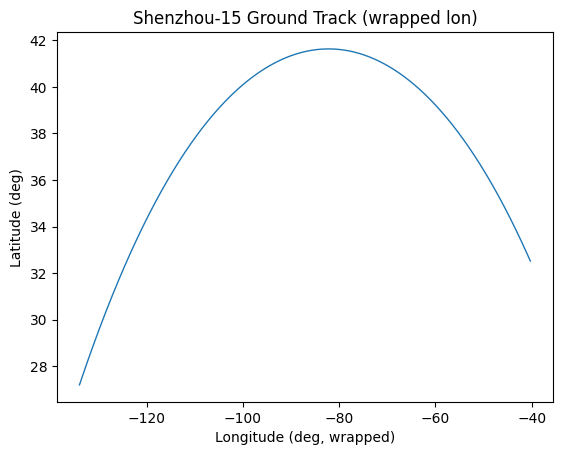

In [ ]:
import matplotlib.pyplot as plt

lats = [p.lat for p in track_points]
lons = [wrap_lon_deg(p.lon) for p in track_points]

plt.figure()
plt.plot(lons, lats, linewidth=1)
plt.xlabel("Longitude (deg, wrapped)")
plt.ylabel("Latitude (deg)")
plt.title("Shenzhou-15 Ground Track (wrapped lon)")
plt.show()

Overlay Track + Generated Tiles

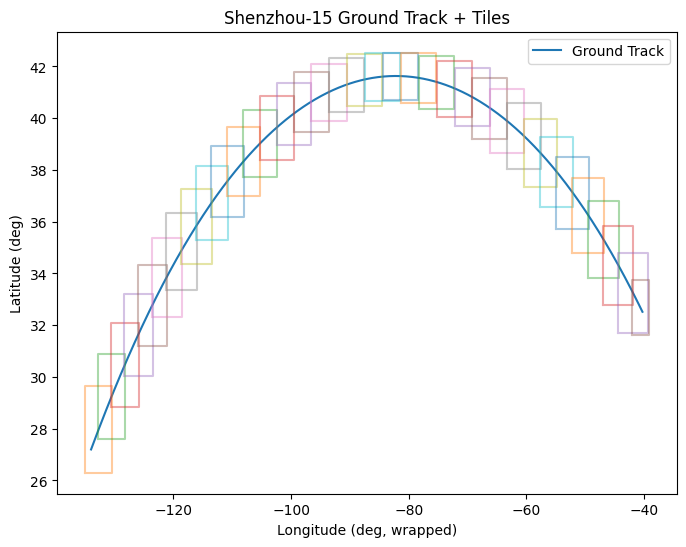

In [ ]:
# Overlay the propagated ground track and the generated tiles.
# This is just a quick visual sanity check to confirm the tiling
# follows the track and behaves reasonably (no jumps or weird boxes).

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Plot ground track (lon wrapped to [-180, 180))
lats = [p.lat for p in track_points]
lons = [wrap_lon_deg(p.lon) for p in track_points]
plt.plot(lons, lats, linewidth=1.5, label="Ground Track")

# Draw each visited box
for bw in box_windows:
    box = bw.box

    # Normal case
    if box.lon_min <= box.lon_max:
        rect_lon = [box.lon_min, box.lon_max, box.lon_max,
                    box.lon_min, box.lon_min]
        rect_lat = [box.lat_min, box.lat_min, box.lat_max,
                    box.lat_max, box.lat_min]
        plt.plot(rect_lon, rect_lat, alpha=0.4)

    # Dateline-crossing case (split for plotting)
    else:
        rect_lat = [box.lat_min, box.lat_min, box.lat_max,
                    box.lat_max, box.lat_min]
        plt.plot([-180, box.lon_max, box.lon_max, -180, -180],
                 rect_lat, alpha=0.4)
        plt.plot([box.lon_min, 180, 180, box.lon_min, box.lon_min],
                 rect_lat, alpha=0.4)

plt.xlabel("Longitude (deg, wrapped)")
plt.ylabel("Latitude (deg)")
plt.title("Shenzhou-15 Ground Track + Tiles")
plt.legend()
plt.show()

Cartopy Setup

In [ ]:
!pip -q install cartopy

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

Cartopy Map: Ground Track + Tiles

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


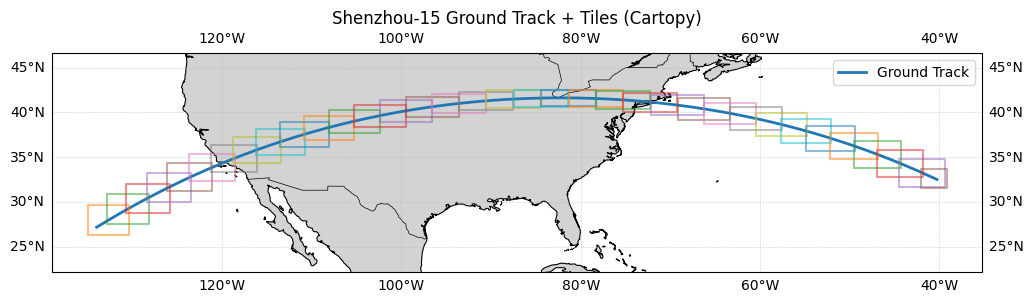

In [ ]:
# Plot the ground track + tile rectangles on a Cartopy map.
# This is the same sanity check as before, just on a real basemap.

# Track arrays
track_lats = np.array([p.lat for p in track_points], dtype=float)
track_lons = np.array([wrap_lon_deg(p.lon) for p in track_points], dtype=float)

# A reasonable map extent around the data (with a little padding)
pad_deg = 5.0
min_lon = float(track_lons.min() - pad_deg)
max_lon = float(track_lons.max() + pad_deg)
min_lat = float(track_lats.min() - pad_deg)
max_lat = float(track_lats.max() + pad_deg)

fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Basemap features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.4, linestyle="--", alpha=0.6)

# Plot track
ax.plot(track_lons, track_lats, transform=ccrs.PlateCarree(), linewidth=2.0, label="Ground Track")

# Plot tiles
for bw in box_windows:
    box = bw.box

    # Normal case: lon_min <= lon_max
    if box.lon_min <= box.lon_max:
        rect_lons = [box.lon_min, box.lon_max, box.lon_max, box.lon_min, box.lon_min]
        rect_lats = [box.lat_min, box.lat_min, box.lat_max, box.lat_max, box.lat_min]
        ax.plot(rect_lons, rect_lats, transform=ccrs.PlateCarree(), alpha=0.5)

    # Dateline-crossing case: split into two rectangles
    else:
        rect_lats = [box.lat_min, box.lat_min, box.lat_max, box.lat_max, box.lat_min]

        rect_lons_1 = [-180.0, box.lon_max, box.lon_max, -180.0, -180.0]
        rect_lons_2 = [box.lon_min, 180.0, 180.0, box.lon_min, box.lon_min]

        ax.plot(rect_lons_1, rect_lats, transform=ccrs.PlateCarree(), alpha=0.5)
        ax.plot(rect_lons_2, rect_lats, transform=ccrs.PlateCarree(), alpha=0.5)

ax.set_title("Shenzhou-15 Ground Track + Tiles (Cartopy)")
ax.legend()
plt.show()

Tile Summary Stats

In [ ]:
# Quick sanity stats on tiles + windows

durations_sec = [(bw.t_exit - bw.t_enter).total_seconds() for bw in box_windows]
dl_durations_sec = [(bw.t_download_end - bw.t_download_start).total_seconds() for bw in box_windows]

print("Boxes visited:", len(box_windows))
print("Median in-box duration (s):", float(np.median(durations_sec)))
print("Max in-box duration (s):   ", float(np.max(durations_sec)))
print("Median download window (min):", float(np.median(dl_durations_sec))/60.0)
print("Max download window (min):   ", float(np.max(dl_durations_sec))/60.0)

# Show the longest 5 download windows
worst = sorted(box_windows, key=lambda bw: (bw.t_download_end - bw.t_download_start), reverse=True)[:5]
for bw in worst:
    mins = (bw.t_download_end - bw.t_download_start).total_seconds()/60.0
    print(bw.box.box_id, "download window (min):", round(mins, 2),
          "enter:", bw.t_enter.isoformat(), "exit:", bw.t_exit.isoformat())

Boxes visited: 35
Median in-box duration (s): 42.0
Max in-box duration (s):    42.0
Median download window (min): 15.7
Max download window (min):    15.7
box_000 download window (min): 15.7 enter: 2024-04-02T08:40:00+00:00 exit: 2024-04-02T08:40:42+00:00
box_001 download window (min): 15.7 enter: 2024-04-02T08:40:35+00:00 exit: 2024-04-02T08:41:17+00:00
box_002 download window (min): 15.7 enter: 2024-04-02T08:41:10+00:00 exit: 2024-04-02T08:41:52+00:00
box_003 download window (min): 15.7 enter: 2024-04-02T08:41:45+00:00 exit: 2024-04-02T08:42:27+00:00
box_004 download window (min): 15.7 enter: 2024-04-02T08:42:20+00:00 exit: 2024-04-02T08:43:02+00:00


Build Download Requests (Dry Run)

In [ ]:
# Build download rectangles + time windows (no downloading yet)

def lon_intervals_for_box(box: GeoBox):
    if box.lon_min <= box.lon_max:
        return [(box.lon_min, box.lon_max)]
    return [(-180.0, box.lon_max), (box.lon_min, 180.0)]

download_requests = []
for bw in box_windows:
    for lon_min, lon_max in lon_intervals_for_box(bw.box):
        download_requests.append({
            "box_id": bw.box.box_id,
            "lat_min": bw.box.lat_min,
            "lat_max": bw.box.lat_max,
            "lon_min": lon_min,
            "lon_max": lon_max,
            "t_start_utc": bw.t_download_start,
            "t_end_utc": bw.t_download_end,
        })

print("Download rectangles:", len(download_requests))
print(download_requests[0])

Download rectangles: 35
{'box_id': 'box_000', 'lat_min': 26.298501744448057, 'lat_max': 29.637712071205748, 'lon_min': np.float64(-135.01448451430645), 'lon_max': np.float64(-130.38442913056215), 't_start_utc': datetime.datetime(2024, 4, 2, 8, 38, tzinfo=datetime.timezone.utc), 't_end_utc': datetime.datetime(2024, 4, 2, 8, 53, 42, tzinfo=datetime.timezone.utc)}


Save Download Requests JSON

In [ ]:
import json
from pathlib import Path

out_dir = Path(output_base) / event_name
out_dir.mkdir(parents=True, exist_ok=True)

req_path = out_dir / "download_requests.json"

jsonable = []
for r in download_requests:
    jsonable.append({
        "box_id": r["box_id"],
        "lat_min": r["lat_min"],
        "lat_max": r["lat_max"],
        "lon_min": r["lon_min"],
        "lon_max": r["lon_max"],
        "t_start_utc": r["t_start_utc"].isoformat(),
        "t_end_utc": r["t_end_utc"].isoformat(),
    })

with open(req_path, "w", encoding="utf-8") as f:
    json.dump(jsonable, f, indent=2)

print("Wrote:", req_path)

Wrote: /content/drive/MyDrive/Johns_Hopkins_University/Seismic_Research/raw/shenzhou15_20240402T084000Z_to_20240402T090000Z/download_requests.json


Choose One Box to Test

In [ ]:
test_req = download_requests[len(download_requests)//2]
print("Testing:", test_req)

Testing: {'box_id': 'box_017', 'lat_min': 40.48802199052625, 'lat_max': 42.47232915975798, 'lon_min': np.float64(-90.53244410370196), 'lon_max': np.float64(-84.4661710018237), 't_start_utc': datetime.datetime(2024, 4, 2, 8, 47, 55, tzinfo=datetime.timezone.utc), 't_end_utc': datetime.datetime(2024, 4, 2, 9, 3, 37, tzinfo=datetime.timezone.utc)}


MassDownloader Single-Box Test

In [ ]:
from obspy import UTCDateTime
from obspy.clients.fdsn.mass_downloader import MassDownloader, RectangularDomain, Restrictions

domain = RectangularDomain(
    minlatitude=test_req["lat_min"],
    maxlatitude=test_req["lat_max"],
    minlongitude=test_req["lon_min"],
    maxlongitude=test_req["lon_max"],
)

restrictions = Restrictions(
    starttime=UTCDateTime(test_req["t_start_utc"]),
    endtime=UTCDateTime(test_req["t_end_utc"]),
    # Broad for the first test; tighten later
    channel_priorities=["HHZ", "BHZ"],
    location_priorities=["", "00", "10", "20"],
    reject_channels_with_gaps=True,
    minimum_length=0.9,
)

mdl = MassDownloader(providers=["IRIS"])  # change to your provider list if needed

box_dir = Path(output_base) / event_name / "boxes" / test_req["box_id"]
inv_dir = box_dir / "stations"
wav_dir = box_dir / "waveforms"

mdl.download(
    domain,
    restrictions,
    mseed_storage=str(wav_dir),
    stationxml_storage=str(inv_dir) + "/{network}.{station}.xml",
)

print("Downloaded to:", box_dir)

[2026-03-06 14:48:11,027] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for IRIS.
[2026-03-06 14:48:11,027] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for IRIS.
[2026-03-06 14:48:11,036] - obspy.clients.fdsn.mass_downloader - INFO: Successfully initialized 1 client(s): IRIS.
[2026-03-06 14:48:11,036] - obspy.clients.fdsn.mass_downloader - INFO: Successfully initialized 1 client(s): IRIS.
[2026-03-06 14:48:11,042] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexisting stations: 0
[2026-03-06 14:48:11,042] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexisting stations: 0
[2026-03-06 14:48:11,046] - obspy.clients.fdsn.mass_downloader - INFO: Client 'IRIS' - Requesting reliable availability.
[2026-03-06 14:48:11,046] - obspy.clients.fdsn.mass_downloader - INFO: Client 'IRIS' - Requesting reliable availability.
[2026-03-06 14:48:11,307] - obspy.clients.fdsn.mass_downloader - INFO: Client 'IRIS'

Downloaded to: /content/drive/MyDrive/Johns_Hopkins_University/Seismic_Research/raw/shenzhou15_20240402T084000Z_to_20240402T090000Z/boxes/box_017


Confirm MiniSEED Exists in Drive

In [ ]:
from pathlib import Path
from obspy import read

# Use the correct run folder
run_folder = RAW / "shenzhou15_20240402T084000Z_to_20240402T090000Z"
boxes_folder = run_folder / "boxes"

print("Boxes folder:", boxes_folder)
print("Exists:", boxes_folder.exists())

# Find all .mseed under this run
mseed_files = sorted([p for p in boxes_folder.rglob("*.mseed") if p.is_file()])

print("Total .mseed files found:", len(mseed_files))
for p in mseed_files[:5]:
    print(" -", p.relative_to(run_folder))

# Load one to verify
if mseed_files:
    st = read(str(mseed_files[0]))
    print(st)
    print("First trace start/end:", st[0].stats.starttime, st[0].stats.endtime)
else:
    print("No MiniSEED found under boxes/")

Boxes folder: /content/drive/MyDrive/Johns_Hopkins_University/Seismic_Research/raw/shenzhou15_20240402T084000Z_to_20240402T090000Z/boxes
Exists: True
Total .mseed files found: 893
 - boxes/box_005/waveforms/{network}.{station}.{location}.{channel}.mseed/BK.PABC.00.HHZ__20240402T084055Z__20240402T085637Z.mseed
 - boxes/box_005/waveforms/{network}.{station}.{location}.{channel}.mseed/CI.ABL..HHZ__20240402T084055Z__20240402T085637Z.mseed
 - boxes/box_005/waveforms/{network}.{station}.{location}.{channel}.mseed/CI.BAI..HHZ__20240402T084055Z__20240402T085637Z.mseed
 - boxes/box_005/waveforms/{network}.{station}.{location}.{channel}.mseed/CI.BAK..HHZ__20240402T084055Z__20240402T085637Z.mseed
 - boxes/box_005/waveforms/{network}.{station}.{location}.{channel}.mseed/CI.BCH..HHZ__20240402T084055Z__20240402T085637Z.mseed
1 Trace(s) in Stream:
BK.PABC.00.HHZ | 2024-04-02T08:40:55.000470Z - 2024-04-02T08:56:36.990470Z | 100.0 Hz, 94200 samples
First trace start/end: 2024-04-02T08:40:55.000470Z 202

Load + Inspect One Waveform (Raw Check)

mseed: 893
xml: 0
first mseed: BK.PABC.00.HHZ__20240402T084055Z__20240402T085637Z.mseed
1 Trace(s) in Stream:
BK.PABC.00.HHZ | 2024-04-02T08:40:55.000470Z - 2024-04-02T08:56:36.990470Z | 100.0 Hz, 94200 samples
Trace ID: BK.PABC.00.HHZ
Start: 2024-04-02T08:40:55.000470Z | End: 2024-04-02T08:56:36.990470Z | Fs: 100.0


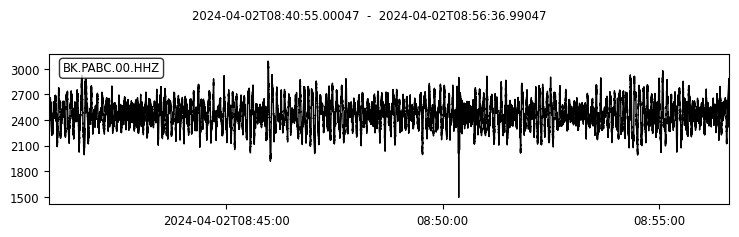

In [ ]:
from pathlib import Path
from obspy import read, read_inventory

# Paths (use existing RUN/WAVE/META variables)
# Use recursive search and only keep actual files, not directories
mseed_files = sorted([p for p in WAVE.rglob("*.mseed") if p.is_file()])
xml_files   = sorted([p for p in META.rglob("*.xml") if p.is_file()])

print("mseed:", len(mseed_files))
print("xml:", len(xml_files))

if not mseed_files:
    print("No MiniSEED files found under:", WAVE)
else:
    print("first mseed:", mseed_files[0].name)

    # Load one waveform file
    st = read(str(mseed_files[0]))
    print(st)

    tr = st[0]
    print("Trace ID:", tr.id)
    print("Start:", tr.stats.starttime, "| End:", tr.stats.endtime, "| Fs:", tr.stats.sampling_rate)

    # Quick plot (raw)
    tr.plot()

Download All Boxes (Waveforms + StationXML) + Plot Stations

[2026-03-06 14:50:59,673] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for IRIS, SCEDC, NCEDC.
[2026-03-06 14:50:59,673] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for IRIS, SCEDC, NCEDC.
[2026-03-06 14:50:59,673] - obspy.clients.fdsn.mass_downloader - INFO: Initializing FDSN client(s) for IRIS, SCEDC, NCEDC.
[2026-03-06 14:50:59,834] - obspy.clients.fdsn.mass_downloader - INFO: Successfully initialized 3 client(s): IRIS, SCEDC, NCEDC.
[2026-03-06 14:50:59,834] - obspy.clients.fdsn.mass_downloader - INFO: Successfully initialized 3 client(s): IRIS, SCEDC, NCEDC.
[2026-03-06 14:50:59,834] - obspy.clients.fdsn.mass_downloader - INFO: Successfully initialized 3 client(s): IRIS, SCEDC, NCEDC.
[2026-03-06 14:50:59,848] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexisting stations: 0
[2026-03-06 14:50:59,848] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexisting stations: 0
[2026-03-06 14:50:

[1/35] downloading box_000 ...


[2026-03-06 14:51:00,196] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available for request.
[2026-03-06 14:51:00,196] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available for request.
[2026-03-06 14:51:00,196] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available for request.
[2026-03-06 14:51:00,200] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available.
[2026-03-06 14:51:00,200] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available.
[2026-03-06 14:51:00,200] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available.
[2026-03-06 14:51:00,203] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexisting stations: 0
[2026-03-06 14:51:00,203] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexisting stations: 0
[2026-03-06 14:51:00,203] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexis

[2/35] downloading box_001 ...


[2026-03-06 14:51:00,859] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available for request.
[2026-03-06 14:51:00,859] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available for request.
[2026-03-06 14:51:00,859] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available for request.
[2026-03-06 14:51:00,863] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available.
[2026-03-06 14:51:00,863] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available.
[2026-03-06 14:51:00,863] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available.
[2026-03-06 14:51:00,865] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexisting stations: 0
[2026-03-06 14:51:00,865] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexisting stations: 0
[2026-03-06 14:51:00,865] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexis

...

[34/35] downloading box_033 ...


[2026-03-06 14:51:09,695] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available for request.
[2026-03-06 14:51:09,695] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available for request.
[2026-03-06 14:51:09,695] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available for request.
[2026-03-06 14:51:09,699] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available.
[2026-03-06 14:51:09,699] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available.
[2026-03-06 14:51:09,699] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available.
[2026-03-06 14:51:09,705] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexisting stations: 0
[2026-03-06 14:51:09,705] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexisting stations: 0
[2026-03-06 14:51:09,705] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexis

[35/35] downloading box_034 ...


[2026-03-06 14:51:10,350] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available for request.
[2026-03-06 14:51:10,350] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available for request.
[2026-03-06 14:51:10,350] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available for request.
[2026-03-06 14:51:10,354] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available.
[2026-03-06 14:51:10,354] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available.
[2026-03-06 14:51:10,354] - obspy.clients.fdsn.mass_downloader - INFO: Client 'SCEDC' - No data available.
[2026-03-06 14:51:10,357] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexisting stations: 0
[2026-03-06 14:51:10,357] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexisting stations: 0
[2026-03-06 14:51:10,357] - obspy.clients.fdsn.mass_downloader - INFO: Total acquired or preexis


=== Download Summary ===
OK: 16 | Skipped: 19 | Failed: 0
Wrote manifest: /content/drive/MyDrive/Johns_Hopkins_University/Seismic_Research/raw/shenzhou15_20240402T084000Z_to_20240402T090000Z/download_manifest.json

StationXML files found: 891
Unique stations (downloaded candidates): 353
Stations within 100.0 km of track: 199 / 353


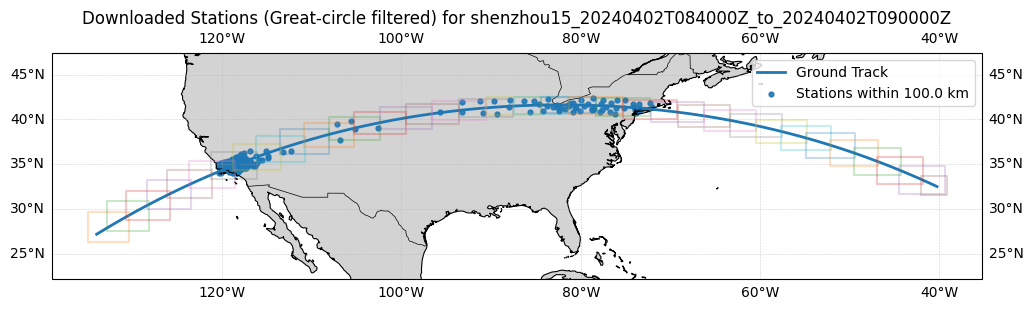

In [ ]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

from obspy import UTCDateTime, read_inventory
from obspy.clients.fdsn.mass_downloader import MassDownloader, RectangularDomain, Restrictions

# ----------------------------
# 1) Download over ALL requests
# ----------------------------
def get_mseed_path(network, station, location, channel, starttime, endtime):
    loc = location if location else ""
    return str(wav_dir / f"{network}.{station}.{loc}.{channel}.mseed")

run_folder = Path(output_base) / event_name
boxes_root = run_folder / "boxes"
boxes_root.mkdir(parents=True, exist_ok=True)

mdl = MassDownloader(providers=["IRIS", "SCEDC", "NCEDC"])  # adjust if you want other providers

results = []
n_ok = 0
n_skip = 0
n_fail = 0

for k, req in enumerate(download_requests, start=1):
    box_id = req["box_id"]
    box_dir = boxes_root / box_id
    inv_dir = box_dir / "stations"
    wav_dir = box_dir / "waveforms"
    log_dir = box_dir / "logs"

    inv_dir.mkdir(parents=True, exist_ok=True)
    wav_dir.mkdir(parents=True, exist_ok=True)
    log_dir.mkdir(parents=True, exist_ok=True)

    # Skip if it looks like we already downloaded something meaningful
    already_has_mseed = any(wav_dir.rglob("*.mseed"))
    already_has_xml = any(inv_dir.rglob("*.xml"))
    if already_has_mseed and already_has_xml:
        n_skip += 1
        results.append({"box_id": box_id, "status": "skipped_existing"})
        continue

    domain = RectangularDomain(
        minlatitude=req["lat_min"],
        maxlatitude=req["lat_max"],
        minlongitude=req["lon_min"],
        maxlongitude=req["lon_max"],
    )

    restrictions = Restrictions(
        starttime=UTCDateTime(req["t_start_utc"]),
        endtime=UTCDateTime(req["t_end_utc"]),
        channel_priorities=["HHZ", "BHZ"],
        location_priorities=["", "00", "10", "20"],
        reject_channels_with_gaps=True,
        minimum_length=0.9,
    )

    try:
        print(f"[{k}/{len(download_requests)}] downloading {box_id} ...")

        mdl.download(
            domain,
            restrictions,
            mseed_storage=get_mseed_path,
            stationxml_storage=str(inv_dir / "{network}.{station}.xml"),
        )

        n_ok += 1
        results.append({"box_id": box_id, "status": "ok"})
    except Exception as e:
        n_fail += 1
        results.append({"box_id": box_id, "status": "failed", "error": repr(e)})
        print("  FAILED:", box_id, "->", repr(e))

print("\n=== Download Summary ===")
print("OK:", n_ok, "| Skipped:", n_skip, "| Failed:", n_fail)

# Save a simple manifest so you can prove what happened
manifest_path = run_folder / "download_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(
        {
            "event_name": event_name,
            "total_requests": len(download_requests),
            "ok": n_ok,
            "skipped_existing": n_skip,
            "failed": n_fail,
            "results": results,
        },
        f,
        indent=2,
        default=str,
    )
print("Wrote manifest:", manifest_path)

# ------------------------------------------
# 2) Parse StationXMLs and plot station dots
# ------------------------------------------

station_rows = []
xml_files = sorted(boxes_root.rglob("stations/*.xml"))

print("\nStationXML files found:", len(xml_files))

for xml in xml_files:
    try:
        inv = read_inventory(str(xml))
        for net in inv:
            for sta in net:
                station_rows.append(
                    {
                        "network": net.code,
                        "station": sta.code,
                        "lat": float(sta.latitude),
                        "lon": float(sta.longitude),
                    }
                )
    except Exception as e:
        # keep going even if one xml is weird
        print("Could not read:", xml, "->", repr(e))

if not station_rows:
    print("No stations parsed from StationXML (nothing to plot).")
else:
    # Dedupe by network+station
    seen = set()
    uniq = []
    for r in station_rows:
        key = (r["network"], r["station"])
        if key not in seen:
            seen.add(key)
            uniq.append(r)

    print("Unique stations (downloaded candidates):", len(uniq))

    # -------------------------------------------------------
    # GREAT-CIRCLE FILTER: keep stations near track
    # -------------------------------------------------------
    buffer_km = 100.0  # corridor half-width (match earlier choice)

    if "track_points" not in globals() or len(track_points) == 0:
        raise RuntimeError("track_points not found; run the orbit propagation cell first.")

    kept = []
    for r in uniq:
        d_km = min_distance_km_to_track(r["lat"], r["lon"], track_points)
        if d_km <= buffer_km:
            r["min_dist_km"] = d_km
            kept.append(r)

    print(f"Stations within {buffer_km} km of track: {len(kept)} / {len(uniq)}")

    # Replace uniq with filtered stations for plotting
    uniq = kept

    if not uniq:
        print("No stations within corridor after great-circle filtering; nothing to plot.")
    else:
        st_lats = np.array([r["lat"] for r in uniq], dtype=float)
        st_lons = np.array([wrap_lon_deg(r["lon"]) for r in uniq], dtype=float)

        # Plot on Cartopy if available (you already installed it earlier)
        import cartopy.crs as ccrs
        import cartopy.feature as cfeature

        # Use track extents if track_points exists; otherwise fallback to station extents
        if "track_points" in globals() and len(track_points) > 0:
            track_lats = np.array([p.lat for p in track_points], dtype=float)
            track_lons = np.array([wrap_lon_deg(p.lon) for p in track_points], dtype=float)

            pad_deg = 5.0
            min_lon = float(min(track_lons.min(), st_lons.min()) - pad_deg)
            max_lon = float(max(track_lons.max(), st_lons.max()) + pad_deg)
            min_lat = float(min(track_lats.min(), st_lats.min()) - pad_deg)
            max_lat = float(max(track_lats.max(), st_lats.max()) + pad_deg)
        else:
            pad_deg = 5.0
            min_lon = float(st_lons.min() - pad_deg)
            max_lon = float(st_lons.max() + pad_deg)
            min_lat = float(st_lats.min() - pad_deg)
            max_lat = float(st_lats.max() + pad_deg)

        fig = plt.figure(figsize=(12, 7))
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

        ax.add_feature(cfeature.LAND, facecolor="lightgray")
        ax.add_feature(cfeature.OCEAN, facecolor="white")
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.gridlines(draw_labels=True, linewidth=0.4, linestyle="--", alpha=0.6)

        # Track (if present)
        if "track_points" in globals() and len(track_points) > 0:
            ax.plot(track_lons, track_lats, transform=ccrs.PlateCarree(), linewidth=2.0, label="Ground Track")

        # Tiles (if present)
        if "box_windows" in globals() and len(box_windows) > 0:
            for bw in box_windows:
                box = bw.box
                if box.lon_min <= box.lon_max:
                    rect_lons = [box.lon_min, box.lon_max, box.lon_max, box.lon_min, box.lon_min]
                    rect_lats = [box.lat_min, box.lat_min, box.lat_max, box.lat_max, box.lat_min]
                    ax.plot(rect_lons, rect_lats, transform=ccrs.PlateCarree(), alpha=0.25)
                else:
                    rect_lats = [box.lat_min, box.lat_min, box.lat_max, box.lat_max, box.lat_min]
                    rect_lons_1 = [-180.0, box.lon_max, box.lon_max, -180.0, -180.0]
                    rect_lons_2 = [box.lon_min, 180.0, 180.0, box.lon_min, box.lon_min]
                    ax.plot(rect_lons_1, rect_lats, transform=ccrs.PlateCarree(), alpha=0.25)
                    ax.plot(rect_lons_2, rect_lats, transform=ccrs.PlateCarree(), alpha=0.25)

        # Stations (filtered)
        ax.scatter(st_lons, st_lats, transform=ccrs.PlateCarree(), s=12, alpha=0.9,
                   label=f"Stations within {buffer_km} km")

        ax.set_title(f"Downloaded Stations (Great-circle filtered) for {event_name}")
        ax.legend()
        plt.show()